# importing **lib**

In [8]:
!pip install matplotlib

In [9]:
!pip install Pillow

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
# from google.colab import drive  # Uncomment if running on Google Colab
import os
import hashlib
from PIL import Image  # This now works with Pillow installed
import numpy as np
import matplotlib.pyplot as plt

print("All modules imported successfully!")

All modules imported successfully!


# **EDA**

In [11]:
def data(dataset_path):
    images = []
    labels = []
    for subfolder in os.listdir(dataset_path):
        subfolder_path = os.path.join(dataset_path, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
        for image_filename in os.listdir(subfolder_path):
            if image_filename.endswith(".jpg"):
                image_path = os.path.join(subfolder_path, image_filename)
                images.append(image_path)
                labels.append(subfolder)
    df = pd.DataFrame({'image': images, 'label': labels})
    return df

In [12]:
import os

base_dir = r'D:\BoneFractureClassification-main\dataset'   # change if needed

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [13]:
import pandas as pd

train = data(train_dir)
val = data(val_dir)
test = data(test_dir)


## Visualizing our data

In [14]:

# prompt: distribution of the classes

import os

def count_classes(directory):
  class_counts = {}
  for class_name in os.listdir(directory):
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path):
      class_counts[class_name] = len(os.listdir(class_path))
  return class_counts

train_counts = count_classes(train_dir)
val_counts = count_classes(val_dir)
test_counts = count_classes(test_dir)

print("Training set distribution:", train_counts)
print("Validation set distribution:", val_counts)
print("Test set distribution:", test_counts)


Training set distribution: {'fractured': 2079, 'not fractured': 2020}
Validation set distribution: {'fractured': 169, 'not fractured': 237}
Test set distribution: {'fractured': 200, 'not fractured': 201}


In [15]:
def count_classes(directory):
    class_counts = {}
    
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    
    return class_counts

In [16]:
print("Function exists:", 'count_classes' in globals())

Function exists: True


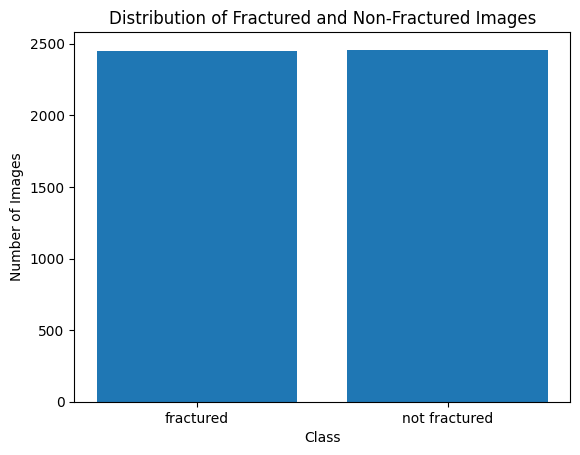

fractured: 2448 images
not fractured: 2458 images


In [17]:
# prompt: distribution of fractured and non fractured and visualize



# Combine counts from all sets
# Combine counts from all sets
if 'train_counts' not in globals() or 'val_counts' not in globals() or 'test_counts' not in globals():
    train_counts = count_classes(train_dir)
    val_counts = count_classes(val_dir)
    test_counts = count_classes(test_dir)

all_counts = {
    'fractured': train_counts.get('fractured', 0) + val_counts.get('fractured', 0) + test_counts.get('fractured', 0),
    'not fractured': train_counts.get('not fractured', 0) + val_counts.get('not fractured', 0) + test_counts.get('not fractured', 0)
}



plt.bar(all_counts.keys(), all_counts.values())
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Fractured and Non-Fractured Images')
plt.show()

# Print the exact numbers
for class_name, count in all_counts.items():
    print(f"{class_name}: {count} images")


# **Displaying our images**

In [18]:
pip install tensorflow numpy pandas matplotlib pillow scikit-learn seaborn opencv-python tqdm

Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
import cv2

print(np.__version__)
print("OpenCV working ✅")

1.23.5
OpenCV working ✅


In [20]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras
from keras.callbacks import EarlyStopping,ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tqdm import tqdm

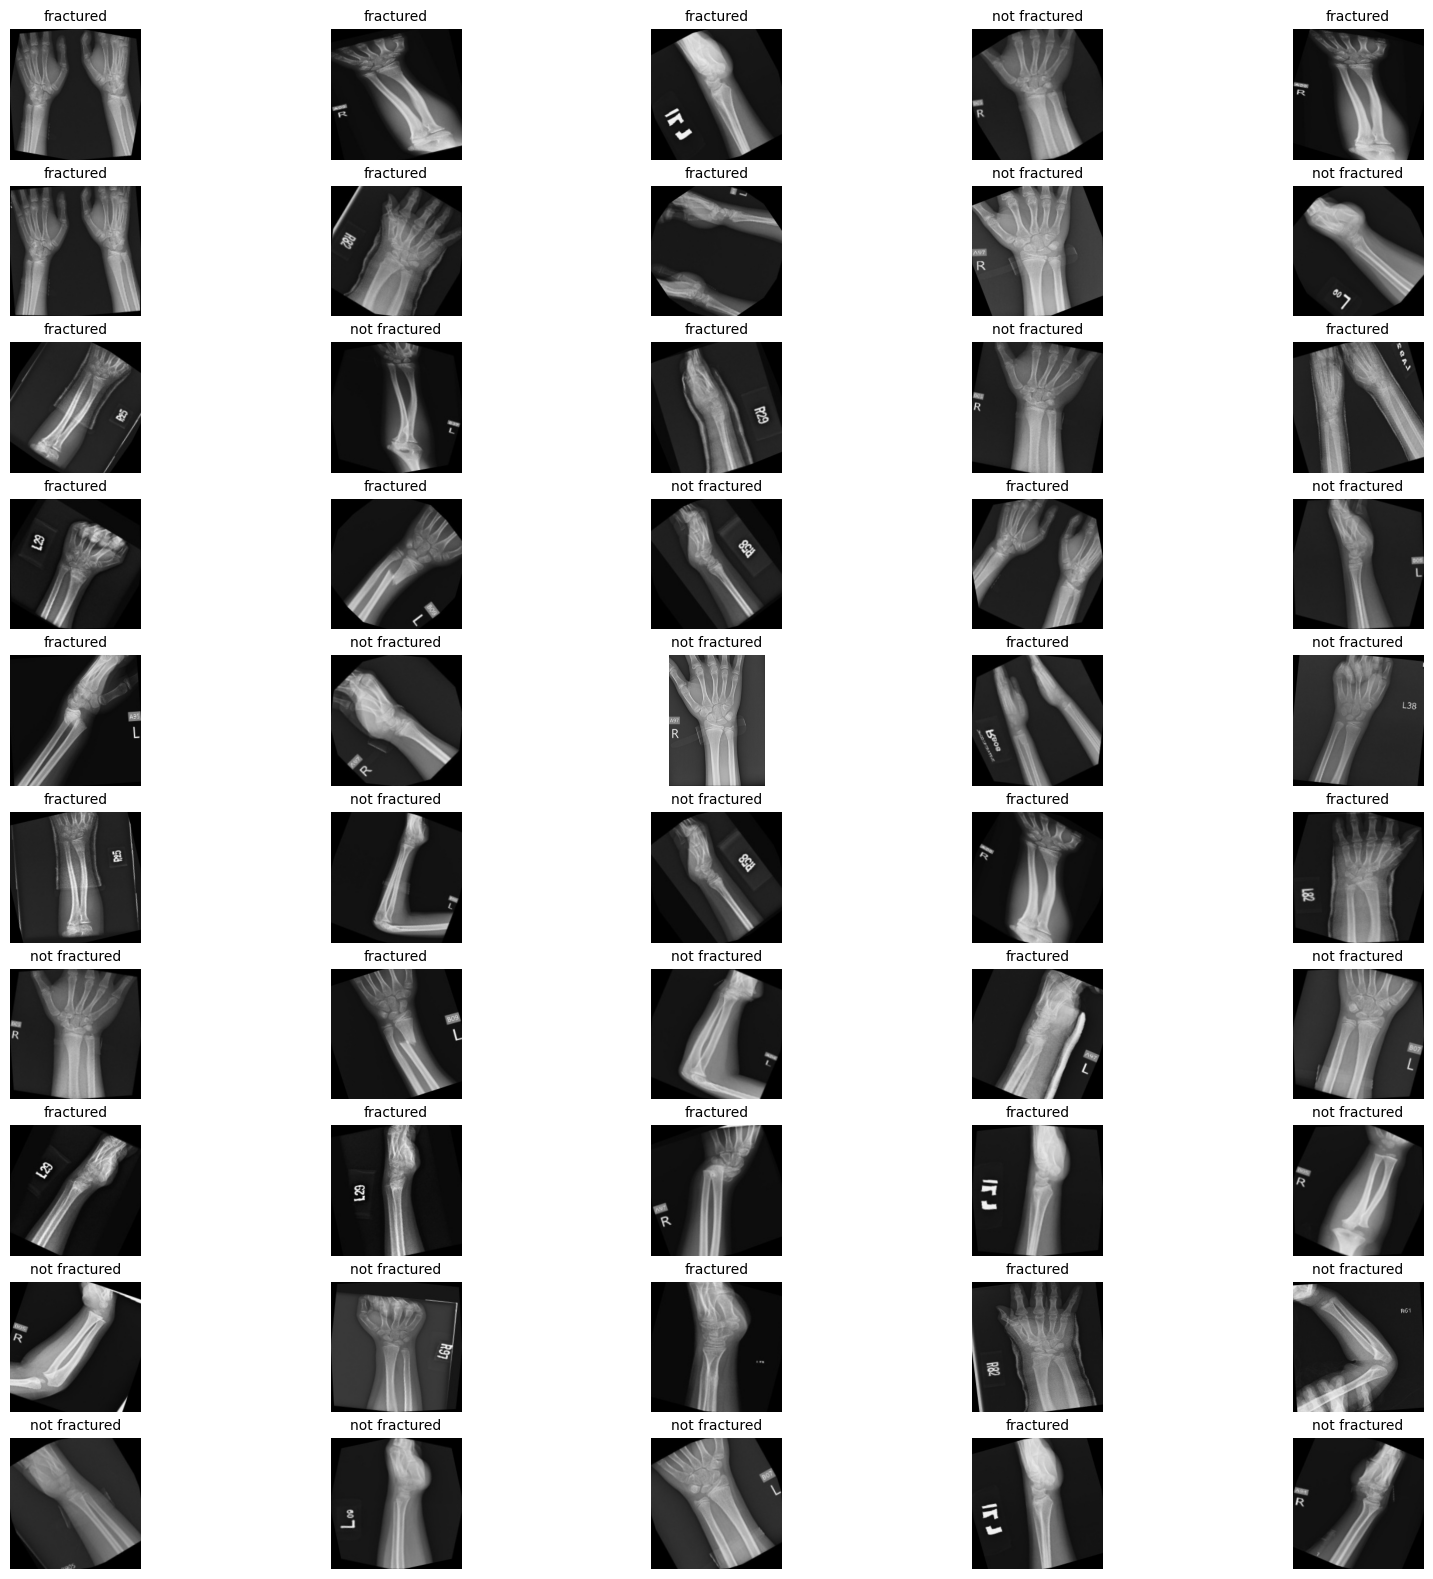

In [21]:
# Define data function if not already defined
if 'data' not in globals():
    def data(dataset_path):
        images = []
        labels = []
        for subfolder in os.listdir(dataset_path):
            subfolder_path = os.path.join(dataset_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for image_filename in os.listdir(subfolder_path):
                if image_filename.endswith(".jpg"):
                    image_path = os.path.join(subfolder_path, image_filename)
                    images.append(image_path)
                    labels.append(subfolder)
        df = pd.DataFrame({'image': images, 'label': labels})
        return df

# Ensure dataset paths exist if prior setup cells were not executed
if 'train_dir' not in globals() or 'val_dir' not in globals() or 'test_dir' not in globals():
    base_dir = r'D:\BoneFractureClassification-main\dataset'
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'val')
    test_dir = os.path.join(base_dir, 'test')

# Load data if not already loaded
if 'train' not in globals():
    train = data(train_dir)
    val = data(val_dir)
    test = data(test_dir)

plt.figure(figsize=(20,20))
for n, i in enumerate(np.random.randint(0, len(train), 50)):
    plt.subplot(10, 5, n+1)
    img = cv2.imread(train.image[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # IMPORTANT (fix colors)
    plt.imshow(img)
    plt.axis('off')
    plt.title(train.label[i], fontsize=10)

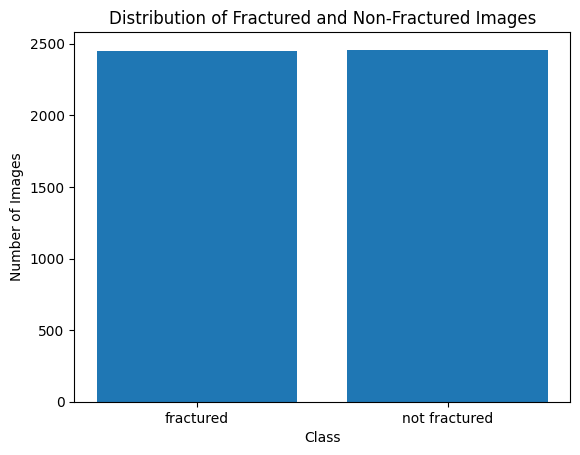

fractured: 2448 images
not fractured: 2458 images


In [22]:
# prompt: distribution of fractured and non fractured and visualize

if 'count_classes' not in globals():
    def count_classes(directory):
        class_counts = {}
        for class_name in os.listdir(directory):
            class_path = os.path.join(directory, class_name)
            if os.path.isdir(class_path):
                class_counts[class_name] = len([name for name in os.listdir(class_path) if name.lower().endswith('.jpg')])
        return class_counts

if 'train_dir' not in globals() or 'val_dir' not in globals() or 'test_dir' not in globals():
    base_dir = r'D:\BoneFractureClassification-main\dataset'
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'val')
    test_dir = os.path.join(base_dir, 'test')

if 'train_counts' not in globals() or 'val_counts' not in globals() or 'test_counts' not in globals():
    train_counts = count_classes(train_dir)
    val_counts = count_classes(val_dir)
    test_counts = count_classes(test_dir)

all_counts = {
    'fractured': train_counts.get('fractured', 0) + val_counts.get('fractured', 0) + test_counts.get('fractured', 0),
    'not fractured': train_counts.get('not fractured', 0) + val_counts.get('not fractured', 0) + test_counts.get('not fractured', 0)
}

plt.bar(all_counts.keys(), all_counts.values())
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Fractured and Non-Fractured Images')
plt.show()

# Print the exact numbers
for class_name, count in all_counts.items():
    print(f"{class_name}: {count} images")

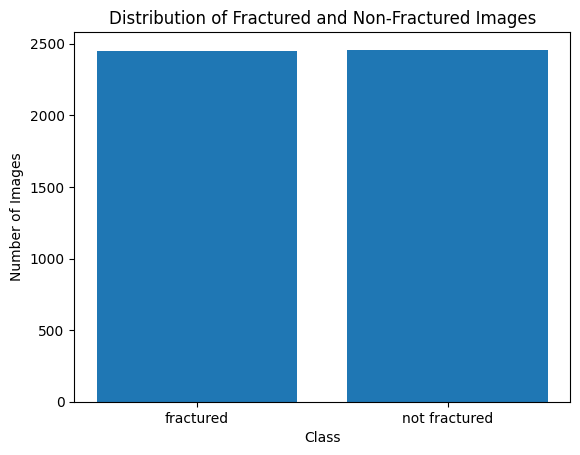

fractured: 2448 images
not fractured: 2458 images


In [23]:
# prompt: distribution of fractured and non fractured and visualize

if 'count_classes' not in globals():
    def count_classes(directory):
        class_counts = {}
        for class_name in os.listdir(directory):
            class_path = os.path.join(directory, class_name)
            if os.path.isdir(class_path):
                class_counts[class_name] = len([name for name in os.listdir(class_path) if name.lower().endswith('.jpg')])
        return class_counts

if 'train_dir' not in globals() or 'val_dir' not in globals() or 'test_dir' not in globals():
    base_dir = r'D:\BoneFractureClassification-main\dataset'
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'val')
    test_dir = os.path.join(base_dir, 'test')

if 'train_counts' not in globals() or 'val_counts' not in globals() or 'test_counts' not in globals():
    train_counts = count_classes(train_dir)
    val_counts = count_classes(val_dir)
    test_counts = count_classes(test_dir)

all_counts = {
    'fractured': train_counts.get('fractured', 0) + val_counts.get('fractured', 0) + test_counts.get('fractured', 0),
    'not fractured': train_counts.get('not fractured', 0) + val_counts.get('not fractured', 0) + test_counts.get('not fractured', 0)
}

plt.bar(all_counts.keys(), all_counts.values())
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Fractured and Non-Fractured Images')
plt.show()

# Print the exact numbers
for class_name, count in all_counts.items():
    print(f"{class_name}: {count} images")

# **Data Generators**

In [24]:
image_size = (224, 224)
batch_size = 32
datagen = ImageDataGenerator(
    rescale=1./255
)
train_generator = datagen.flow_from_dataframe(
    train,
    x_col='image',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)
test_generator = datagen.flow_from_dataframe(
    test,
    x_col='image',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)
val_generator = datagen.flow_from_dataframe(
    val,
    x_col='image',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

Found 4097 validated image filenames belonging to 2 classes.
Found 399 validated image filenames belonging to 2 classes.
Found 404 validated image filenames belonging to 2 classes.


# **ResNet_50**

In [25]:
import os

# 👇 CHANGE THIS PATH according to your system
base_dir = r'D:\BoneFractureClassification-main\dataset'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

In [26]:
from PIL import Image
print("PIL working ✅")

PIL working ✅


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 4097 images belonging to 2 classes.
Found 404 images belonging to 2 classes.


In [28]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
resnet_base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in resnet_base_model.layers:
    layer.trainable = False

resnet_model = Sequential()
resnet_model.add(resnet_base_model)
resnet_model.add(GlobalAveragePooling2D())
resnet_model.add(Dense(256, activation='relu'))
resnet_model.add(Dense(1, activation='sigmoid'))

resnet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

resnet_history = resnet_model.fit(train_generator, epochs=10, validation_data=val_generator)

# Fine-tuning ResNet50 model by unfreezing some layers
for layer in resnet_base_model.layers[-10:]:
    layer.trainable = True

resnet_model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

fine_tuned_resnet_history = resnet_model.fit(train_generator, epochs=10, validation_data=val_generator)


Epoch 1/10
129/129 [==============================] - 51s 251ms/step - loss: 0.6926 - accuracy: 0.5275 - val_loss: 0.7082 - val_accuracy: 0.4158
Epoch 2/10
129/129 [==============================] - 27s 210ms/step - loss: 0.6761 - accuracy: 0.5536 - val_loss: 0.6552 - val_accuracy: 0.6584
Epoch 3/10
129/129 [==============================] - 26s 200ms/step - loss: 0.6641 - accuracy: 0.5768 - val_loss: 0.6423 - val_accuracy: 0.6980
Epoch 4/10
129/129 [==============================] - 24s 187ms/step - loss: 0.6551 - accuracy: 0.6146 - val_loss: 0.6306 - val_accuracy: 0.6980
Epoch 5/10
129/129 [==============================] - 24s 186ms/step - loss: 0.6423 - accuracy: 0.6580 - val_loss: 0.6323 - val_accuracy: 0.7748
Epoch 6/10
129/129 [==============================] - 25s 194ms/step - loss: 0.6359 - accuracy: 0.6583 - val_loss: 0.6441 - val_accuracy: 0.5842
Epoch 7/10
129/129 [==============================] - 26s 203ms/step - loss: 0.6308 - accuracy: 0.6468 - val_loss: 0.6232 - val_ac

In [29]:
import os

# Let's print exactly what Python thinks your path is
print(f"Your test_dir is currently set to: \n{test_dir}\n")

# Let's ask Windows if this folder actually exists
if os.path.exists(test_dir):
    print("✅ SUCCESS: Python found your folder! The generator should work now.")
else:
    print("❌ ERROR: Python cannot find this folder on your computer.")

Your test_dir is currently set to: 
D:\BoneFractureClassification-main\dataset\test

✅ SUCCESS: Python found your folder! The generator should work now.


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# ==========================================
# 1. ADDED: DEFINE THE TEST GENERATOR FIRST
# ==========================================
# Notice the 'r' before the quote
test_dir = r"D:\BoneFractureClassification-main\dataset\test"# <--- REPLACE WITH YOUR ACTUAL PATH

# Apply the same preprocessing you used for your training data
test_datagen = ImageDataGenerator(rescale=1./255) 

# Create the test_generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224), # ResNet standard input size; adjust if yours is different
    batch_size=32,
    class_mode='binary',    # Based on your '> 0.5' code, this is binary classification
    shuffle=False           # IMPORTANT: Setting this to False here ensures predictions align with labels
)

# ==========================================
# 2. EVALUATE AND PREDICT
# ==========================================
# Note: Ensure 'resnet_model' is already defined, trained, or loaded before this line!

# Evaluate model
test_loss, test_accuracy = resnet_model.evaluate(test_generator)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy}')

# Predictions
test_preds = resnet_model.predict(test_generator)

# Convert probabilities to binary
test_preds = (test_preds > 0.5).astype(int).reshape(-1)

# True labels
test_labels = test_generator.classes

# ==========================================
# 3. PRINT METRICS
# ==========================================
# Classification report
print('\n--- Classification Report ---')
print(classification_report(test_labels, test_preds, target_names=list(test_generator.class_indices.keys())))

# Confusion matrix
print('\n--- Confusion Matrix ---')
print(confusion_matrix(test_labels, test_preds))

# Metrics
accuracy = accuracy_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)

print('\n--- Additional Metrics ---')
print(f'Accuracy: {accuracy}')
print(f'F1 score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Found 399 images belonging to 2 classes.
13/13 [==============================] - 3s 197ms/step - loss: 0.1091 - accuracy: 0.9574
Test loss: 0.10906819999217987
Test accuracy: 0.9573934674263
13/13 [==============================] - 5s 186ms/step

--- Classification Report ---
               precision    recall  f1-score   support

    fractured       0.99      0.92      0.96       199
not fractured       0.93      0.99      0.96       200

     accuracy                           0.96       399
    macro avg       0.96      0.96      0.96       399
 weighted avg       0.96      0.96      0.96       399


--- Confusion Matrix ---
[[184  15]
 [  2 198]]

--- Additional Metrics ---
Accuracy: 0.9573934837092731
F1 score: 0.9588377723970944
Precision: 0.9295774647887324
Recall: 0.99


In [31]:
import matplotlib.pyplot as plt

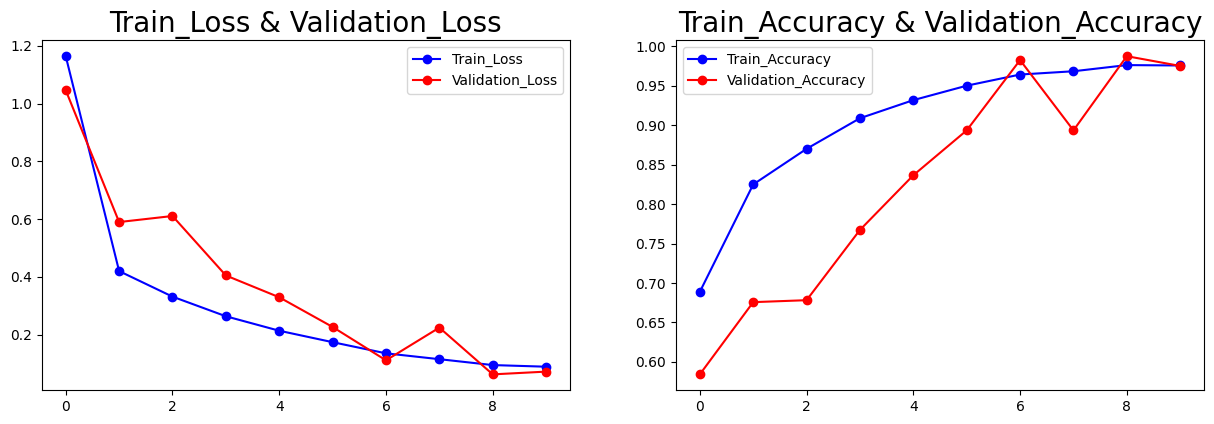

In [32]:
plt.figure(figsize=(15,10))

# Loss
plt.subplot(2,2,1)
plt.plot(fine_tuned_resnet_history.history['loss'],'b-o',label='Train_Loss')
plt.plot(fine_tuned_resnet_history.history['val_loss'],'r-o',label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()

# Accuracy
plt.subplot(2,2,2)
plt.plot(fine_tuned_resnet_history.history['accuracy'],'b-o',label='Train_Accuracy')
plt.plot(fine_tuned_resnet_history.history['val_accuracy'],'r-o',label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

# Specificity (FIXED)
if 'specificity_at_sensitivity' in fine_tuned_resnet_history.history:
    plt.subplot(2,2,3)
    plt.plot(fine_tuned_resnet_history.history['specificity_at_sensitivity'],'b-o',
             label='Train_specificity_at_sensitivity')
    plt.plot(fine_tuned_resnet_history.history['val_specificity_at_sensitivity'],'r-o',
             label='Validation_specificity_at_sensitivity')
    plt.title('Train_Sensitivity & Validation_Sensitivity',fontsize=20)
    plt.legend()

# AUC
if 'auc' in fine_tuned_resnet_history.history:
    plt.subplot(2,2,4)
    plt.plot(fine_tuned_resnet_history.history['auc'],'b-o',label='Train_auc')
    plt.plot(fine_tuned_resnet_history.history['val_auc'],'r-o',label='Validation_auc')
    plt.title('Train_AUC & Validation_AUC',fontsize=20)
    plt.legend()

plt.show()

# VGG-**16**

In [33]:
from tensorflow.keras.applications import VGG16

In [34]:
from tensorflow.keras.layers import Flatten

In [35]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
import os
import tensorflow as tf

print("GPU will be used if available")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# =========================
# GENERATORS
# =========================
train_dir = r"D:\BoneFractureClassification-main\dataset\train" 
val_dir = r"D:\BoneFractureClassification-main\dataset\val"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(128, 128), batch_size=16, class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(128, 128), batch_size=16, class_mode='binary'
)

# =========================
# MODEL
# =========================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in base_model.layers[-4:]:
    layer.trainable = True

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN
# =========================
print("\nStarting training on GPU (if available)...")

history = model.fit(
    train_generator, 
    epochs=10, 
    validation_data=val_generator
)

GPU will be used if available
Found 4097 images belonging to 2 classes.
Found 404 images belonging to 2 classes.

Starting training on GPU (if available)...
Epoch 1/10
257/257 [==============================] - 81s 271ms/step - loss: 0.3644 - accuracy: 0.8257 - val_loss: 0.1298 - val_accuracy: 0.9530
Epoch 2/10
257/257 [==============================] - 66s 257ms/step - loss: 0.0524 - accuracy: 0.9812 - val_loss: 0.0487 - val_accuracy: 0.9876
Epoch 3/10
257/257 [==============================] - 55s 214ms/step - loss: 0.0443 - accuracy: 0.9807 - val_loss: 0.0178 - val_accuracy: 0.9975
Epoch 4/10
257/257 [==============================] - 52s 201ms/step - loss: 0.0270 - accuracy: 0.9919 - val_loss: 0.0101 - val_accuracy: 0.9950
Epoch 5/10
257/257 [==============================] - 48s 188ms/step - loss: 0.0435 - accuracy: 0.9849 - val_loss: 0.0220 - val_accuracy: 0.9876
Epoch 6/10
257/257 [==============================] - 39s 153ms/step - loss: 0.0055 - accuracy: 0.9990 - val_loss: 8.1

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 4097 images belonging to 2 classes.
Found 404 images belonging to 2 classes.


In [41]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Enable memory growth (important)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        print("GPU is being used")
    except RuntimeError as e:
        print(e)
else:
    print("GPU not found, using CPU")

Physical devices cannot be modified after being initialized


In [42]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

Num GPUs Available: 1
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =========================
# CREATE TEST GENERATOR
# =========================
test_dir = r"D:\BoneFractureClassification-main\dataset\test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=8,   # 🔥 safer (avoid crash)
    class_mode='binary',
    shuffle=False
)

# =========================
# EVALUATION
# =========================
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy}')

test_preds = model.predict(test_generator)
test_preds = (test_preds > 0.5).astype(int)

test_labels = test_generator.classes

print('Classification Report')
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=list(test_generator.class_indices.keys())
))

print('Confusion Matrix')
print(confusion_matrix(test_labels, test_preds))

Found 399 images belonging to 2 classes.
50/50 [==============================] - 4s 58ms/step - loss: 1.1913e-05 - accuracy: 1.0000
Test loss: 1.1913358321180567e-05
Test accuracy: 1.0
50/50 [==============================] - 2s 30ms/step
Classification Report
               precision    recall  f1-score   support

    fractured       1.00      1.00      1.00       199
not fractured       1.00      1.00      1.00       200

     accuracy                           1.00       399
    macro avg       1.00      1.00      1.00       399
 weighted avg       1.00      1.00      1.00       399

Confusion Matrix
[[199   0]
 [  0 200]]


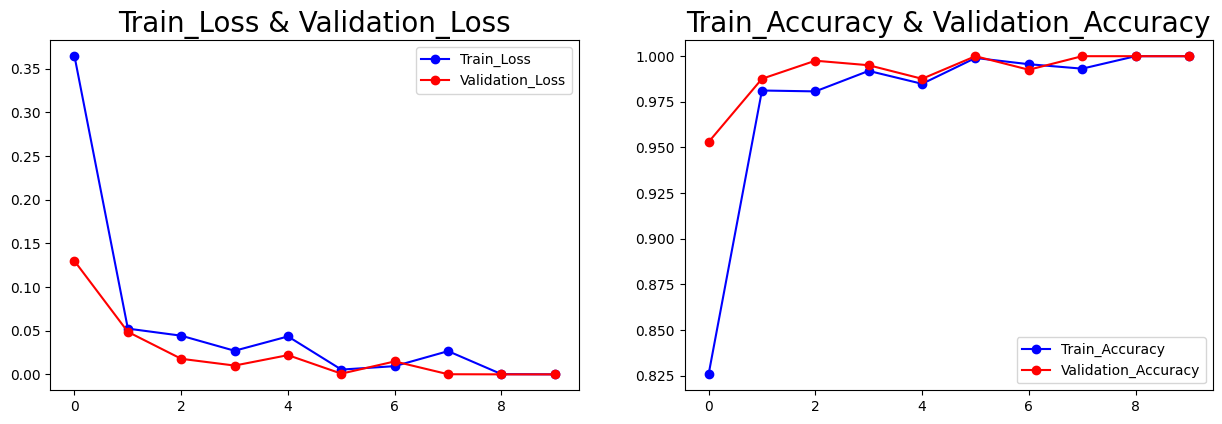

In [44]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.plot(history.history['loss'],'b-o',label='Train_Loss') # Use history.history to access the metrics
plt.plot(history.history['val_loss'],'r-o',label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(2,2,2)
plt.plot(history.history['accuracy'],'b-o',label='Train_Accuracy')
plt.plot(history.history['val_accuracy'],'r-o',label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()
# Check if 'specificity_at_sensitivity' and 'auc' are available in your history
if 'specificity_at_sensitivity' in history.history:
    plt.subplot(2,2,3)
    plt.plot(history.history['specificity_at_sensitivity'],'b-o',label='Train_specificity_at_sensitivity')
    plt.plot(history.history['val_specificity_at_sensitivity'],'r-o',label='Validation_specificity_at_sensitivity')
    plt.title('Train_Sensitivity & Validation_Sensitivity',fontsize=20)
    plt.legend()
if 'auc' in history.history:
    plt.subplot(2,2,4)
    plt.plot(history.history['auc'],'b-o',label='Train_auc')
    plt.plot(history.history['val_auc'],'r-o',label='Validation_auc')
    plt.title('Train_AUC & Validation_AUC',fontsize=20)
    plt.legend()
plt.show()

# **Custom Cnn model**

In [48]:

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
# Build a CNN model from scratch
image_size = (224, 224)
img_height, img_width = image_size
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [49]:
target_size = (128,128)

In [50]:
target_size = (128,128)

In [51]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),   # MUST MATCH TRAINING
    batch_size=8,
    class_mode='binary',
    shuffle=False
)

Found 399 images belonging to 2 classes.


In [53]:
IMG_SIZE = (128,128)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=4,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=4,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=4,
    class_mode='binary',
    shuffle=False
)

Found 4097 images belonging to 2 classes.
Found 404 images belonging to 2 classes.
Found 399 images belonging to 2 classes.


In [57]:
IMG_SIZE = (128,128)

In [58]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=4,
    class_mode='binary'
)

Found 4097 images belonging to 2 classes.


In [59]:
cnn_model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),  # SAME
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [64]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [65]:
# =========================
# BUILD MODEL
# =========================
cnn_model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# =========================
# COMPILE (MISSING STEP)
# =========================
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN
# =========================
cnn_history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
1025/1025 [==============================] - 14s 12ms/step - loss: 0.3204 - accuracy: 0.8604 - val_loss: 0.0781 - val_accuracy: 0.9827
Epoch 2/10
1025/1025 [==============================] - 11s 11ms/step - loss: 0.0688 - accuracy: 0.9763 - val_loss: 0.0123 - val_accuracy: 1.0000
Epoch 3/10
1025/1025 [==============================] - 13s 13ms/step - loss: 0.0225 - accuracy: 0.9915 - val_loss: 0.0052 - val_accuracy: 0.9975
Epoch 4/10
1025/1025 [==============================] - 14s 14ms/step - loss: 0.0205 - accuracy: 0.9922 - val_loss: 0.0347 - val_accuracy: 0.9827
Epoch 5/10
1025/1025 [==============================] - 12s 12ms/step - loss: 0.0192 - accuracy: 0.9939 - val_loss: 0.0084 - val_accuracy: 0.9975
Epoch 6/10
1025/1025 [==============================] - 13s 12ms/step - loss: 0.0083 - accuracy: 0.9980 - val_loss: 4.3151e-04 - val_accuracy: 1.0000
Epoch 7/10
1025/1025 [==============================] - 10s 10ms/step - loss: 2.4768e-04 - accuracy: 1.0000 - val_loss: 

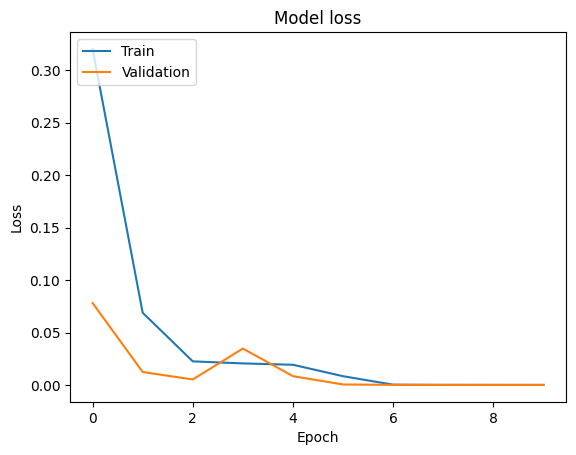

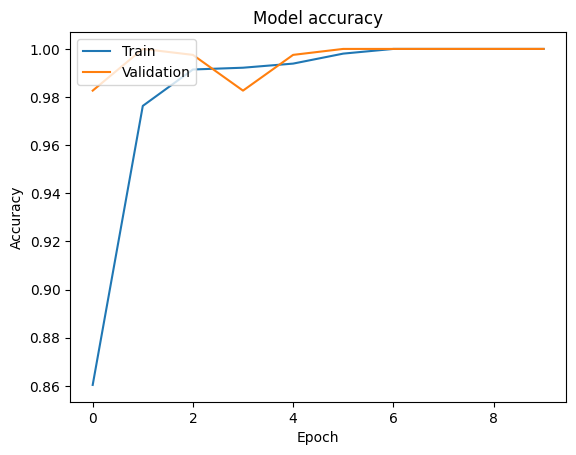

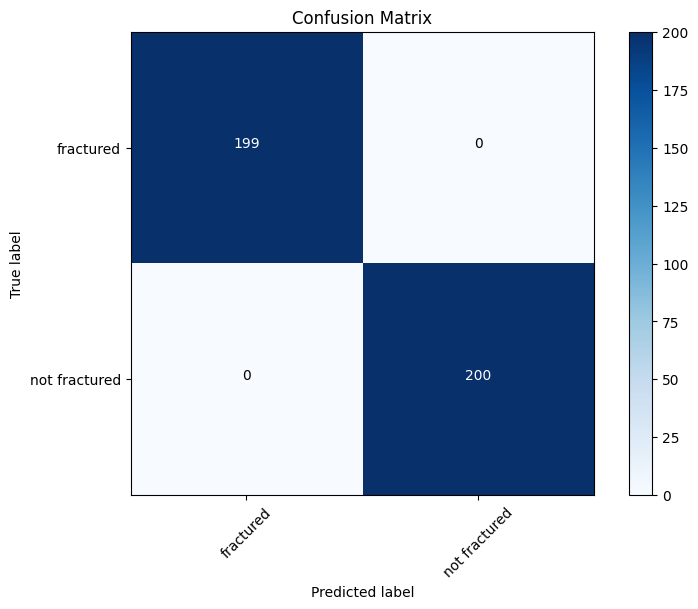

In [66]:
# prompt: visualize the metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score

# Plot training & validation loss values
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(test_generator.class_indices))
plt.xticks(tick_marks, test_generator.class_indices.keys(), rotation=45)
plt.yticks(tick_marks, test_generator.class_indices.keys())

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


# **Comparing the 3 models**



        Model  Accuracy  Validation Accuracy      Loss  Validation Loss
0  Custom CNN  1.000000             1.000000  0.000016         0.000010
1       VGG16  1.000000             1.000000  0.000014         0.000004
2    ResNet50  0.975836             0.975248  0.088728         0.071706


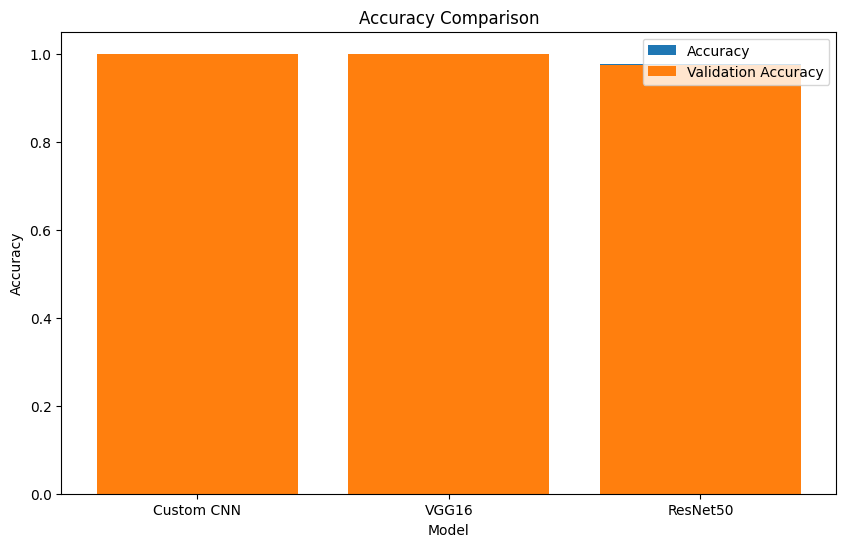

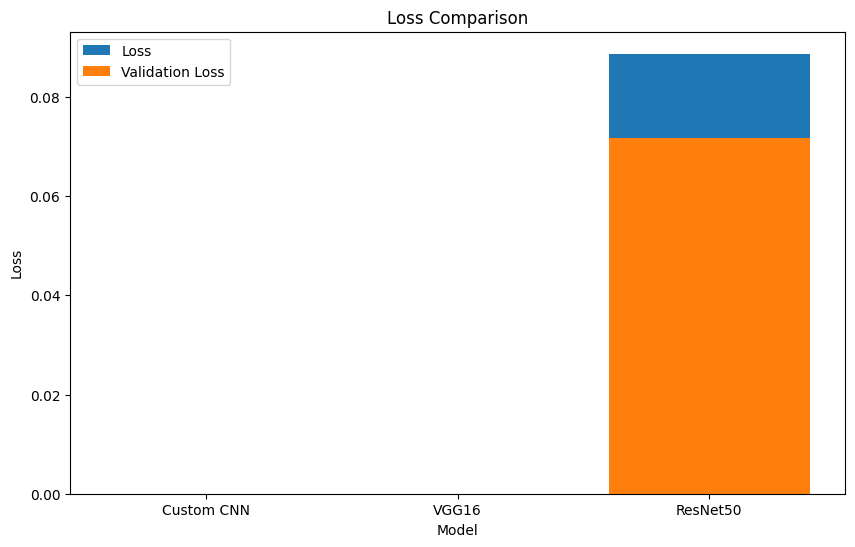

In [67]:
# prompt: visualize the metrics and compare all three models

import pandas as pd
# Extract metrics for each model
cnn_accuracy = cnn_history.history['accuracy'][-1]
cnn_val_accuracy = cnn_history.history['val_accuracy'][-1]
cnn_loss = cnn_history.history['loss'][-1]
cnn_val_loss = cnn_history.history['val_loss'][-1]

vgg_accuracy = history.history['accuracy'][-1]
vgg_val_accuracy = history.history['val_accuracy'][-1]
vgg_loss = history.history['loss'][-1]
vgg_val_loss = history.history['val_loss'][-1]

resnet_accuracy = fine_tuned_resnet_history.history['accuracy'][-1]
resnet_val_accuracy = fine_tuned_resnet_history.history['val_accuracy'][-1]
resnet_loss = fine_tuned_resnet_history.history['loss'][-1]
resnet_val_loss = fine_tuned_resnet_history.history['val_loss'][-1]

# Create a DataFrame for comparison
metrics_df = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16', 'ResNet50'],
    'Accuracy': [cnn_accuracy, vgg_accuracy, resnet_accuracy],
    'Validation Accuracy': [cnn_val_accuracy, vgg_val_accuracy, resnet_val_accuracy],
    'Loss': [cnn_loss, vgg_loss, resnet_loss],
    'Validation Loss': [cnn_val_loss, vgg_val_loss, resnet_val_loss]
})

# Display the DataFrame
print(metrics_df)

# Plotting the metrics
import matplotlib.pyplot as plt

# Accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['Model'], metrics_df['Accuracy'], label='Accuracy')
plt.bar(metrics_df['Model'], metrics_df['Validation Accuracy'], label='Validation Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()
plt.show()

# Loss comparison
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['Model'], metrics_df['Loss'], label='Loss')
plt.bar(metrics_df['Model'], metrics_df['Validation Loss'], label='Validation Loss')
plt.xlabel('Model')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.show()


In [69]:
cnn_history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
1025/1025 [==============================] - 14s 13ms/step - loss: 9.0716e-06 - accuracy: 1.0000 - val_loss: 4.2240e-06 - val_accuracy: 1.0000
Epoch 2/10
1025/1025 [==============================] - 12s 12ms/step - loss: 5.1163e-06 - accuracy: 1.0000 - val_loss: 2.8271e-06 - val_accuracy: 1.0000
Epoch 3/10
1025/1025 [==============================] - 11s 10ms/step - loss: 2.9650e-06 - accuracy: 1.0000 - val_loss: 1.6778e-06 - val_accuracy: 1.0000
Epoch 4/10
1025/1025 [==============================] - 11s 11ms/step - loss: 1.6860e-06 - accuracy: 1.0000 - val_loss: 9.7953e-07 - val_accuracy: 1.0000
Epoch 5/10
1025/1025 [==============================] - 11s 10ms/step - loss: 9.6618e-07 - accuracy: 1.0000 - val_loss: 5.7519e-07 - val_accuracy: 1.0000
Epoch 6/10
1025/1025 [==============================] - 10s 10ms/step - loss: 5.5280e-07 - accuracy: 1.0000 - val_loss: 3.6109e-07 - val_accuracy: 1.0000
Epoch 7/10
1025/1025 [==============================] - 10s 10ms/step - loss

In [70]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# SAVE MODEL
cnn_model.save("fracture_model.h5")
print("Model saved ✅")

Epoch 1/10
1025/1025 [==============================] - 13s 12ms/step - loss: 0.0072 - accuracy: 0.9973 - val_loss: 2.2170e-04 - val_accuracy: 1.0000
Epoch 2/10
1025/1025 [==============================] - 11s 11ms/step - loss: 0.0140 - accuracy: 0.9971 - val_loss: 0.0092 - val_accuracy: 0.9975
Epoch 3/10
1025/1025 [==============================] - 10s 10ms/step - loss: 0.0238 - accuracy: 0.9934 - val_loss: 0.0483 - val_accuracy: 0.9876
Epoch 4/10
1025/1025 [==============================] - 10s 10ms/step - loss: 0.0021 - accuracy: 0.9988 - val_loss: 5.2378e-04 - val_accuracy: 1.0000
Epoch 5/10
1025/1025 [==============================] - 12s 11ms/step - loss: 1.8033e-04 - accuracy: 1.0000 - val_loss: 5.1083e-05 - val_accuracy: 1.0000
Epoch 6/10
1025/1025 [==============================] - 11s 11ms/step - loss: 9.5422e-06 - accuracy: 1.0000 - val_loss: 1.0643e-05 - val_accuracy: 1.0000
Epoch 7/10
1025/1025 [==============================] - 12s 12ms/step - loss: 2.5038e-06 - accuracy: